# 차분(Differencing) 과 이동평균(MA) - Simple Trade Strategy

In [1]:
# !pip install pandas_datareader
#!pip install yfinance

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

## Price difference (익일 종가 - 당일 종가)

PriceDiff = (Close Price of tomorrow - Close Price of today)

shift(period) 함수는 pandas Series나 DataFrame에서 주어진 기간만큼 데이터를 이동시키는 함수입니다. 이를 사용하여 주가 데이터에서 "PriceDiff"를 계산할 수 있습니다.

Yahoo Finance의 yfinance 라이브러리를 사용하여 Meta(Facebook)과 Microsoft의 주가 데이터를 다운로드합니다

In [3]:
fb = yf.download("META", start='2020-01-01', end='2021-12-31', progress=False)    #Meta
ms = yf.download("MSFT", start='2020-01-01', end='2021-12-31', progress=False)  #Microsoft

In [4]:
fb.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-01-02,206.750000,209.789993,206.270004,209.779999,209.779999,12077100
2020-01-03,207.210007,210.399994,206.949997,208.669998,208.669998,11188400
2020-01-06,206.699997,212.779999,206.520004,212.600006,212.600006,17058900
2020-01-07,212.820007,214.580002,211.750000,213.059998,213.059998,14912400
2020-01-08,213.000000,216.240005,212.610001,215.220001,215.220001,13475000


각 데이터프레임에는 'Close'와 'PriceDiff' 열만 남기고 불필요한 column 들을 삭제합니다.

In [5]:
fb.drop(['High', 'Low', 'Open', 'Volume', 'Adj Close'], axis=1, inplace=True)
ms.drop(['High', 'Low', 'Open', 'Volume', 'Adj Close'], axis=1, inplace=True)

이 코드는 Meta(Facebook)의 주가 데이터프레임에 'Yesterday Close'라는 새 열을 추가하고, 종가 데이터를 하루 뒤로 이동시킵니다. 이렇게 하면 'Yesterday Close' 열에 이전 날의 종가 정보가 저장됩니다.

In [6]:
fb['Yesterday Close'] = fb['Close'].shift(1)
fb.head()

,Close,Yesterday Close
Date,,
2020-01-02,209.779999,NaN
2020-01-03,208.669998,209.779999
2020-01-06,212.600006,208.669998
2020-01-07,213.059998,212.600006
2020-01-08,215.220001,213.059998


'Price Difference'라는 새 열을 추가하고, 종가(Close)와 어제 종가(Yesterday Close)의 차이를 계산하여 저장합니다.

In [7]:
#Price Difference - manual 계산
fb['Price Difference'] = fb['Close'] - fb['Yesterday Close']
fb.head()

,Close,Yesterday Close,Price Difference
Date,,,
2020-01-02,209.779999,NaN,NaN
2020-01-03,208.669998,209.779999,-1.110001
2020-01-06,212.600006,208.669998,3.930008
2020-01-07,213.059998,212.600006,0.459991
2020-01-08,215.220001,213.059998,2.160004


Price Diff2'라는 새 열을 추가하고, diff() 메소드를 사용하여 종가(Close) 데이터의 차이를 계산하여 저장합니다. diff() 메소드는 기본적으로 각 데이터 포인트와 그 이전 데이터 포인트의 차이를 계산합니다.  

Manually 계산한 결과와 동일함을 확인할 수 있습니다.

In [8]:
#diff() method 사용해도 동일한 결과
fb['Price Diff2'] = fb['Close'].diff()
fb.head()

,Close,Yesterday Close,Price Difference,Price Diff2
Date,,,,
2020-01-02,209.779999,NaN,NaN,NaN
2020-01-03,208.669998,209.779999,-1.110001,-1.110001
2020-01-06,212.600006,208.669998,3.930008,3.930008
2020-01-07,213.059998,212.600006,0.459991,0.459991
2020-01-08,215.220001,213.059998,2.160004,2.160004


'Yesterday Close'와 'Price Difference'라는 새 열을 추가합니다. 'Yesterday Close' 열에는 이전 날 종가 정보가 저장되고, 'Price Difference' 열에는 종가 데이터의 차이가 계산되어 저장됩니다.

In [9]:
ms['Yesterday Close'] = ms['Close'].shift(1)
ms['Price Difference'] = ms['Close'].diff()
ms.head()

,Close,Yesterday Close,Price Difference
Date,,,
2020-01-02,160.619995,NaN,NaN
2020-01-03,158.619995,160.619995,-2.000000
2020-01-06,159.029999,158.619995,0.410004
2020-01-07,157.580002,159.029999,-1.449997
2020-01-08,160.089996,157.580002,2.509995


데이터프레임에서 '2021-11-03' 날짜의 가격 차이를 출력합니다.

In [10]:
print(ms['Price Difference'].loc['2021-11-03'])

0.8699951171875


### 차분한 값으로부터 원래의 값 복원하기
Microsoft의 주가 데이터프레임에서 'Price Difference' 열을 누적합(cumulative sum)한 결과에 첫 번째 종가(Close) 값을 더하면 원래의 값이 복원됨을 확인할 수 있습니다.

In [11]:
ms['Price Difference'].cumsum() + ms['Close'][0]

Date
2020-01-02           NaN
2020-01-03    158.619995
2020-01-06    159.029999
2020-01-07    157.580002
2020-01-08    160.089996
                 ...    
2021-12-23    334.690002
2021-12-27    342.450012
2021-12-28    341.250000
2021-12-29    341.950012
2021-12-30    339.320007
Name: Price Difference, Length: 504, dtype: float64

## 일일 수익률 계산

- 1 주를 계속 보유하였다고 가정.  

계산 방법. 

- Daily Return = df/df.shift(1) - 1  
    or
- Daily Return[1:] = df[1:] / df[:-1].values - 1  
    or    
- Daily Return = df.pct_chage()

일일 수익률(Daily Return)은 특정 기간(하루) 동안 주식의 가격이 얼마나 상승하거나 하락했는지를 나타내는 지표입니다. 이를 계산하는 방법은 여러 가지가 있지만, 대표적인 방법은 다음과 같습니다.

df/df.shift(1) - 1: 현재 날짜의 주가를 이전 날짜의 주가로 나누어서 1을 빼줍니다. 이전 날짜의 주가를 나타내기 위해 shift() 함수를 사용합니다. 이 방법은 간단하고 이해하기 쉽지만, 첫 번째 데이터에는 NaN이 포함되므로, dropna() 함수를 사용하여 이를 제거해야 합니다.

df[1:] / df[:-1].values - 1: 현재 날짜의 주가를 이전 날짜의 주가로 나누어서 1을 빼줍니다. 이전 날짜의 주가를 나타내기 위해 슬라이싱(slicing)을 사용합니다. 이 방법은 NaN 값이 포함되지 않으므로, 추가적인 처리 없이 사용할 수 있습니다.

df.pct_change(): pct_change() 함수는 현재 날짜의 주가와 이전 날짜의 주가를 사용하여, 가격 변동률을 계산합니다. 이 방법은 간단하고, 첫 번째 데이터에 NaN 값이 포함되지 않으며, 다른 방법들과 동일한 결과를 출력합니다.

In [12]:
ms['Return'] = ms['Close'] / ms['Yesterday Close'] - 1
ms.head()

,Close,Yesterday Close,Price Difference,Return
Date,,,,
2020-01-02,160.619995,NaN,NaN,NaN
2020-01-03,158.619995,160.619995,-2.000000,-0.012452
2020-01-06,159.029999,158.619995,0.410004,0.002585
2020-01-07,157.580002,159.029999,-1.449997,-0.009118
2020-01-08,160.089996,157.580002,2.509995,0.015928


In [13]:
ms['Close'][1:] / ms['Close'][:-1].values - 1

Date
2020-01-03   -0.012452
2020-01-06    0.002585
2020-01-07   -0.009118
2020-01-08    0.015928
2020-01-09    0.012493
                ...   
2021-12-23    0.004472
2021-12-27    0.023186
2021-12-28   -0.003504
2021-12-29    0.002051
2021-12-30   -0.007691
Name: Close, Length: 503, dtype: float64

In [14]:
ms['Close'].pct_change()

Date
2020-01-02         NaN
2020-01-03   -0.012452
2020-01-06    0.002585
2020-01-07   -0.009118
2020-01-08    0.015928
                ...   
2021-12-23    0.004472
2021-12-27    0.023186
2021-12-28   -0.003504
2021-12-29    0.002051
2021-12-30   -0.007691
Name: Close, Length: 504, dtype: float64

'Return' 열을 이용하여 누적 수익율을 계산하고 출력합니다.  

아래 코드를 실행하면 Microsoft 주가 데이터에서 날짜의 범위를 계산하고, 1 주를 계속 보유했을 경우의 누적 수익율을 출력합니다. 

In [15]:
print(f"{len(pd.date_range(ms.index[0], ms.index[-1]))} 일간 1 주를 계속 보유하였다면 누적 수익율은")
print((1+ms['Return']).cumprod())

729 일간 1 주를 계속 보유하였다면 누적 수익율은
Date
2020-01-02         NaN
2020-01-03    0.987548
2020-01-06    0.990101
2020-01-07    0.981073
2020-01-08    0.996700
                ...   
2021-12-23    2.083738
2021-12-27    2.132051
2021-12-28    2.124580
2021-12-29    2.128938
2021-12-30    2.112564
Name: Return, Length: 504, dtype: float64


## 이동평균 - Moving average

다음 코드를 실행하면 Facebook 주가 데이터에서 종가(Close) 열을 이용하여 3일 이동평균을 계산한 후, 결과를 출력합니다

In [16]:
# 3일 이동평균
(fb['Close'] + fb['Close'].shift(1) + fb['Close'].shift(2)) / 3

Date
2020-01-02           NaN
2020-01-03           NaN
2020-01-06    210.350001
2020-01-07    211.443334
2020-01-08    213.626668
                 ...    
2021-12-23    333.296672
2021-12-27    337.289998
2021-12-28    342.546661
2021-12-29    345.113332
2021-12-30    344.506663
Name: Close, Length: 504, dtype: float64

DataFrame.rolling() 을 이용하여 동일한 결과를 얻을 수 있습니다.

In [17]:
fb['Close'].rolling(3).mean()

Date
2020-01-02           NaN
2020-01-03           NaN
2020-01-06    210.350001
2020-01-07    211.443334
2020-01-08    213.626668
                 ...    
2021-12-23    333.296672
2021-12-27    337.289998
2021-12-28    342.546661
2021-12-29    345.113332
2021-12-30    344.506663
Name: Close, Length: 504, dtype: float64

### 이동평균 계산 및 이동평균선 시각화

Facebook 주가 데이터에서 종가(Close) 열을 이용하여 30일 이동평균과 60일 이동평균을 계산한 후, 'ma30' 열과 'ma60' 열에 저장하고 시각화 합니다.

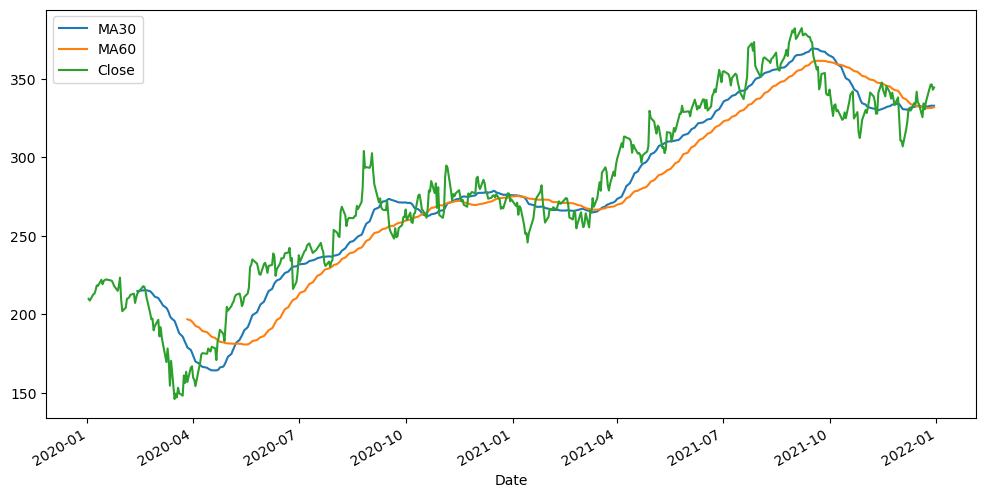

In [18]:
fb['ma30'] = fb['Close'].rolling(30).mean()
fb['ma60'] = fb['Close'].rolling(60).mean()#plot the moving average

#plot the moving average
plt.figure(figsize=(12, 6))
fb['ma30'].plot(label='MA30')
fb['ma60'].plot(label='MA60')
fb['Close'].plot(label='Close')
plt.legend()

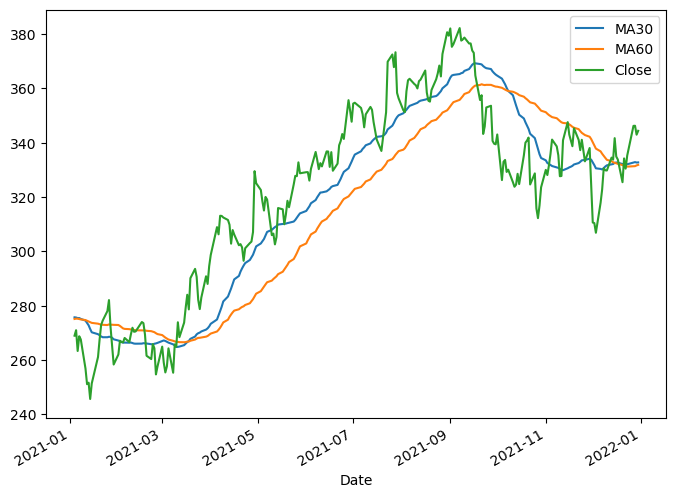

In [19]:
#특정 기간을 slicing한 이동평균 plot
plt.figure(figsize=(8, 6))
fb['ma30'].loc['2021-01-01':'2021-12-31'].plot(label='MA30')
fb['ma60'].loc['2021-01-01':'2021-12-31'].plot(label='MA60')
fb['Close'].loc['2021-01-01':'2021-12-31'].plot(label='Close')
plt.legend()
plt.show()

## EWMA (Exponentially-weighted moving average)


SMA(Simple Moving Average)에는 몇 가지 "약점"이 있습니다.
* window 가 작을수록 신호가 아닌 잡음이 증가합니다.
* 항상 window 크기만큼 지연됩니다.
* 평균화로 인해 데이터의 전체 피크 또는 계곡에 도달하지 않습니다.
* 미래의 움직임에 대해 실제로 알려주지 않습니다. 실제로는 데이터의 trend를 묘사하는 것입니다.
* 극단적인 historical value 로 인해 SMA가 크게 왜곡 될 수 있습니다.

이러한 문제를 해결하기 위해 EWMA (지수 가중 이동 평균)를 사용할 수 있습니다.

In [20]:
df = yf.download('AAPL', start='2021-01-01', end='2021-06-30', progress=False)
df.drop(['Open', 'High', 'Low', 'Adj Close', 'Volume'], axis=1, inplace=True)
df.head()

,Close
Date,
2021-01-04,129.410004
2021-01-05,131.009995
2021-01-06,126.599998
2021-01-07,130.919998
2021-01-08,132.050003


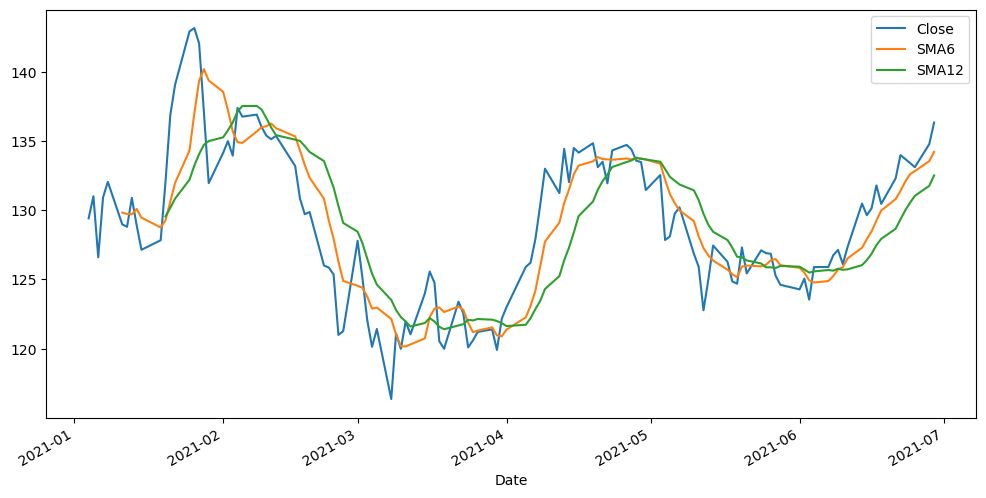

In [21]:
#SMA : Simple Moving Average

df['SMA6'] = df['Close'].rolling(window=6).mean()
df['SMA12'] = df['Close'].rolling(window=12).mean()
df.plot(figsize=(12, 6));

- EWMA를 사용하면 SMA의 지연 효과를 줄일 수 있으며 최근에 발생한 값에 더 많은 가중치를 적용합니다.  

- 가장 최근 값에 적용되는 가중치는 EWMA에 사용된 실제 매개 변수와 window 크기로 지정된 기간에 따라 다릅니다.

EWMA 공식은 다음과 같습니다.

$$ y_t =   \frac{\sum\limits_{i=0}^t w_i x_{t-i}}{\sum\limits_{i=0}^t w_i}$$

$x_t$ 는 입력값, $w_i$ 는 적용된 weight (i=0 에서 t 사이로 변할 수 있음). $y_t$ 는 산출된 값입니다.

In [22]:
df['EWMA12'] = df['Close'].ewm(span=12).mean()
df.tail()

,Close,SMA6,SMA12,EWMA12
Date,,,,
2021-06-23,133.699997,132.063332,129.985832,130.540024
2021-06-24,133.410004,132.606667,130.541665,130.981559
2021-06-25,133.110001,132.826668,131.039999,131.309012
2021-06-28,134.779999,133.546666,131.762499,131.843010
2021-06-29,136.330002,134.218333,132.510832,132.533316


<AxesSubplot:xlabel='Date'>

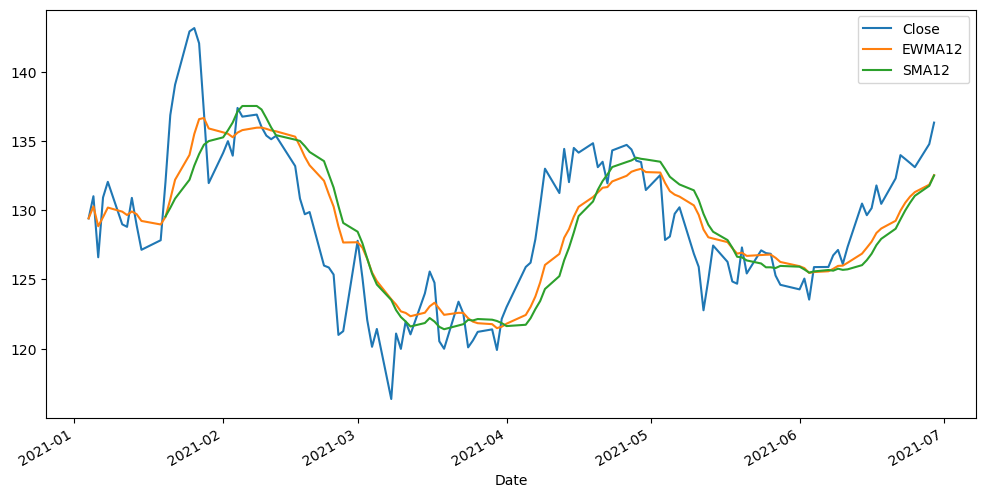

In [23]:
df[['Close', 'EWMA12', 'SMA12']].plot(figsize=(12, 6))

# 이동평균선을 이용한 Simple trading strategy 

이동평균선을 이용한 simple trading strategy는 주식 시장에서 가장 많이 사용되는 기법 중 하나입니다.  
이 기법은 두 개의 이동평균선을 사용합니다. 하나는 단기적인 이동평균선으로서 fast signal, 다른 하나는 장기적인 이동평균선으로서 slow signal 이라고 부릅니다.

fast signal인 10일 이동평균선이 slow signal인 50일 이동평균선 위에 위치하면 추세가 상승하고 있는 것으로 간주하고, 이때 1주를 보유하거나 매수합니다. 반대로, fast signal이 slow signal 밑에 위치하면 추세가 하락하고 있는 것으로 간주하고, 이때 0주를 보유하거나 매도합니다.

이때, 거래비용이 없다고 가정하면 daily profit은 현재 보유한 주식의 수량에 주가의 변동량을 곱한 값입니다. 예를 들어, 1주를 보유하고 있는데 주가가 1% 오르면 daily profit은 1%가 됩니다. 거래비용이 없기 때문에 보유한 주식의 수량이 변하지 않습니다.

위 전략을 따르면서, 투자의 성공 여부를 판단하기 위해 누적 수익을 계산합니다. 누적 수익은 첫 거래일의 종가에 매수한 경우의 누적 수익을 1로 두고, 다음 거래일부터는 각 거래일의 종가에 따라 누적 수익을 계산합니다. 

요약하면,

- fast signal (단기 이동평균) 이 slow signal (장기 이동평균)위에 있으면 1 주 보유, 아래에 있으면 0 주 보유 전략  
- 종가에 매수, 매도 한다고 가정. 거래비용 없다고 가정.

- MA10 > MA50 : 1 주 보유 (매수 or hold), MA10 < MA40 : 0 주 보유 (매도 or no action)  
 
- Daily Profit 계산

- 누적 수익 계산

아래 코드는 Microsoft 주식 데이터에 대해 10일 이동평균과 50일 이동평균을 계산하고, 각각의 일자에서 10일 이동평균이 50일 이동평균보다 크면 1을, 작거나 같으면 0을 반환하는 'Shares' 칼럼을 생성합니다.

즉, 단기 이동평균이 장기 이동평균 위에 있으면 1을, 아래에 있으면 0을 반환하는 것으로, 이를 통해 각 일자에 대해 1주 보유('매수' or 'hold') 할지, 0주 보유('매도' or 'no action') 할지를 결정합니다.

이후 'Shares' 칼럼을 기반으로 daily profit과 누적 수익을 계산하게 됩니다.

In [24]:
ms['MA10'] = ms['Close'].rolling(10).mean()
ms['MA50'] = ms['Close'].rolling(50).mean()
ms['Shares'] = [1 if ms.loc[day, 'MA10'] > ms.loc[day, 'MA50'] else 0 for day in ms.index]
ms.head()

,Close,Yesterday Close,Price Difference,Return,MA10,MA50,Shares
Date,,,,,,,
2020-01-02,160.619995,NaN,NaN,NaN,NaN,NaN,0
2020-01-03,158.619995,160.619995,-2.000000,-0.012452,NaN,NaN,0
2020-01-06,159.029999,158.619995,0.410004,0.002585,NaN,NaN,0
2020-01-07,157.580002,159.029999,-1.449997,-0.009118,NaN,NaN,0
2020-01-08,160.089996,157.580002,2.509995,0.015928,NaN,NaN,0


현재일의 'Close' 가격을 가져와 'shift(-1)' 함수를 사용해 다음날 'NextDay Close' 로 설정합니다.  
이렇게 다음날 종가를 미리 가져와놓으면, 매수/매도 결정을 내리는 것이 더 수월해집니다.

In [25]:
ms['NextDay Close'] = ms['Close'].shift(-1)
ms.head()

,Close,Yesterday Close,Price Difference,Return,MA10,MA50,Shares,NextDay Close
Date,,,,,,,,
2020-01-02,160.619995,NaN,NaN,NaN,NaN,NaN,0,158.619995
2020-01-03,158.619995,160.619995,-2.000000,-0.012452,NaN,NaN,0,159.029999
2020-01-06,159.029999,158.619995,0.410004,0.002585,NaN,NaN,0,157.580002
2020-01-07,157.580002,159.029999,-1.449997,-0.009118,NaN,NaN,0,160.089996
2020-01-08,160.089996,157.580002,2.509995,0.015928,NaN,NaN,0,162.089996


장, 단기 이동평균선을 시각화 합니다.

<AxesSubplot:xlabel='Date'>

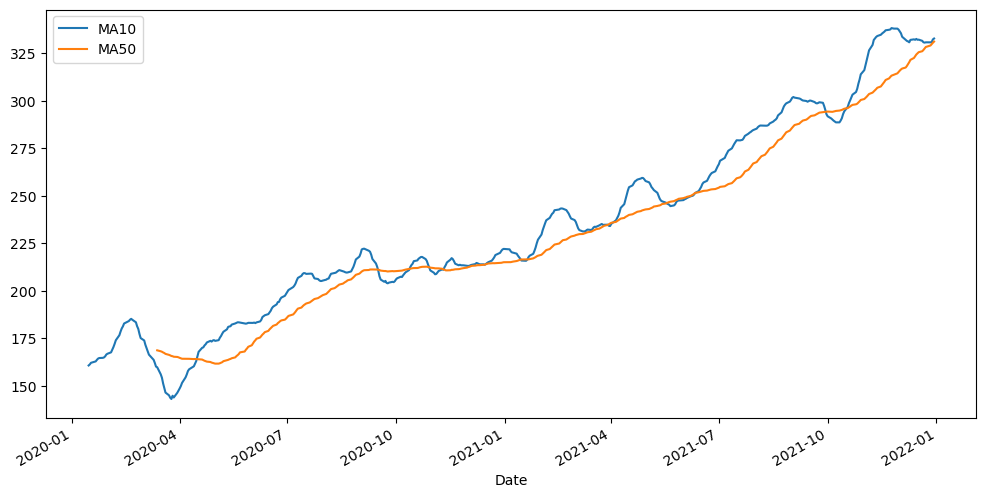

In [26]:
ms[['MA10', 'MA50']].plot(figsize=(12, 6))

## Daily Profit

아래 코드는 일일 수익을 계산하는 코드입니다.

'NextDay Close' 칼럼은 다음 날 종가를 나타내며, 'Close' 칼럼은 당일의 종가를 나타냅니다. 따라서 두 칼럼의 차이를 계산하면 해당 일의 수익을 계산할 수 있습니다.

'Shares' 칼럼이 1인 경우(즉, 'MA10'이 'MA50'보다 큰 경우) 해당 일에 주식 1주를 보유하고 있다는 의미이므로, 해당 일의 수익은 'NextDay Close'에서 'Close'를 뺀 값이 됩니다. 그렇지 않은 경우(즉, 'MA10'이 'MA50'보다 작은 경우) 해당 일에 주식을 보유하지 않으므로 수익은 0이 됩니다.

이렇게 계산한 일일 수익을 'Profit' 칼럼에 저장합니다.

In [27]:
# Daily Profit 계산
ms['Profit'] = [ms.loc[day, 'NextDay Close'] - ms.loc[day, 'Close'] 
                if ms.loc[day, 'Shares'] == 1 else 0 for day in ms.index]

ms.iloc[100:105]

,Close,Yesterday Close,Price Difference,Return,MA10,MA50,Shares,NextDay Close,Profit
Date,,,,,,,,,
2020-05-27,181.809998,181.570007,0.239990,0.001322,182.796001,169.0810,1,181.399994,-0.410004
2020-05-28,181.399994,181.809998,-0.410004,-0.002255,182.961000,169.7776,1,183.250000,1.850006
2020-05-29,183.250000,181.399994,1.850006,0.010198,183.233000,170.6346,1,182.830002,-0.419998
2020-06-01,182.830002,183.250000,-0.419998,-0.002292,183.200000,171.4370,1,184.910004,2.080002
2020-06-02,184.910004,182.830002,2.080002,0.011377,183.200000,172.3882,1,185.360001,0.449997


아래 플롯의 붉은색 선은 수익/손실이 0인 지점을 나타냅니다. 붉은색 선 위쪽에서는 전략이 수익을 창출하고, 아래쪽에서는 손실을 입은 것을 나타냅니다.

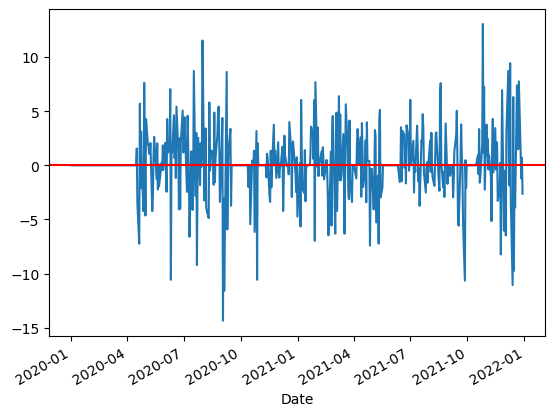

In [28]:
# red line 위쪽은 make money 아래는 lose money
ms['Profit'].plot()
plt.axhline(y=0, color='r')  

## 누적 수익

In [29]:
ms['wealth'] = ms['Profit'].cumsum()
ms.tail()

,Close,Yesterday Close,Price Difference,Return,MA10,MA50,Shares,NextDay Close,Profit,wealth
Date,,,,,,,,,,
2021-12-23,334.690002,333.200012,1.489990,0.004472,330.872000,328.4192,1,342.450012,7.760010,58.900009
2021-12-27,342.450012,334.690002,7.760010,0.023186,330.863000,329.2132,1,341.250000,-1.200012,57.699997
2021-12-28,341.250000,342.450012,-1.200012,-0.003504,331.048001,329.9540,1,341.950012,0.700012,58.400009
2021-12-29,341.950012,341.250000,0.700012,0.002051,332.409003,330.6472,1,339.320007,-2.630005,55.770004
2021-12-30,339.320007,341.950012,-2.630005,-0.007691,332.876004,331.2690,1,NaN,NaN,NaN


이 전략으로 729일 동안 번 수익 : 55.77 


<AxesSubplot:xlabel='Date'>

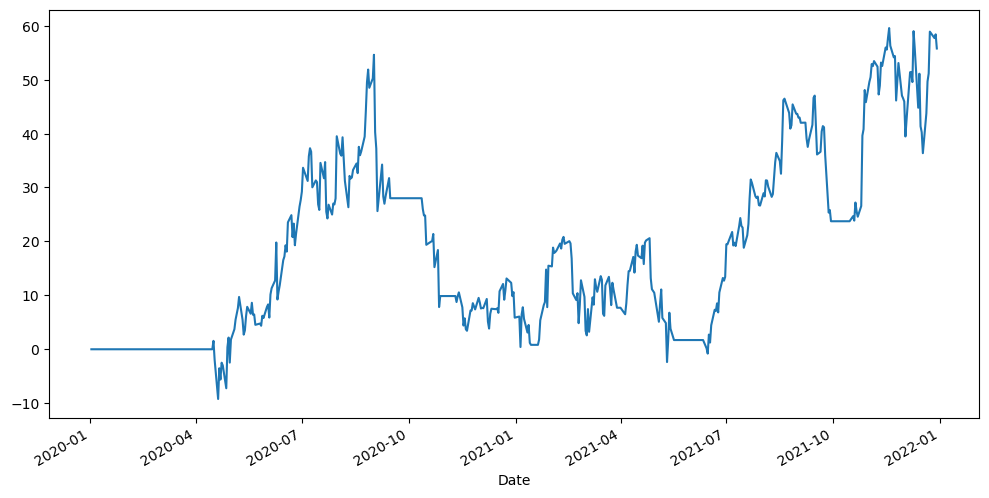

In [30]:
n_days = len(pd.date_range(ms.index[0], ms.index[-1]))

print(f"이 전략으로 {n_days}일 동안 번 수익 : {ms.loc[ms.index[-2], 'wealth']:.2f} ")

plt.figure(figsize=(12, 6))
ms['wealth'].plot()